In [2]:
!pip install vanna==0.6.2 ollama==0.1.6 jupyterlab==4.1.2

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [3]:
!ollama run llama3.2

⠙ ⠙ ⠸ ⠼ ⠴ ⠦ ⠦ ⠇ ⠇ ⠋ ⠙ ⠙ ⠹ ⠼ ⠴ ⠦ ⠦ ⠧ ⠏ ⠏ ⠋ >>> Send a message (/? for help)
Use Ctrl + d or /bye to exit.
>>> Send a message (/? for help)
>>> Send a message (/? for help)

In [6]:
from vanna.ollama import Ollama

In [7]:
import chromadb

In [8]:
from vanna.chromadb import ChromaDB_VectorStore

In [9]:
class MyVanna(ChromaDB_VectorStore, Ollama):
    def __init__(self, config=None):
        ChromaDB_VectorStore.__init__(self, config=config)
        Ollama.__init__(self, config=config)

vn = MyVanna(config={'model': 'llama3.2'})

In [11]:
vn.connect_to_mysql(host='localhost', dbname='Invoice-test', user='root', password='Bhairavidevi@333', port=3306)

In [12]:
# The information schema query may need some tweaking depending on your database. This is a good starting point.
df_information_schema = vn.run_sql("SELECT * FROM INFORMATION_SCHEMA.COLUMNS")

In [13]:
# This will break up the information schema into bite-sized chunks that can be referenced by the LLM
plan = vn.get_training_plan_generic(df_information_schema)
# plan

In [16]:
vn.train(plan=plan)

SQL Prompt: [{'role': 'system', 'content': "You are a SQL expert. Please help to generate a SQL query to answer the question. Your response should ONLY be based on the given context and follow the response guidelines and format instructions. \n===Additional Context \n\nThe following columns are in the InvoiceLine table in the def database:\n\n|      | TABLE_CATALOG   | TABLE_SCHEMA   | TABLE_NAME   | COLUMN_NAME   | DATA_TYPE   | COLUMN_COMMENT   |\n|-----:|:----------------|:---------------|:-------------|:--------------|:------------|:-----------------|\n| 3757 | def             | Chinook        | InvoiceLine  | InvoiceLineId | int         |                  |\n| 3758 | def             | Chinook        | InvoiceLine  | InvoiceId     | int         |                  |\n| 3759 | def             | Chinook        | InvoiceLine  | TrackId       | int         |                  |\n| 3760 | def             | Chinook        | InvoiceLine  | UnitPrice     | decimal     |                  |\n|

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


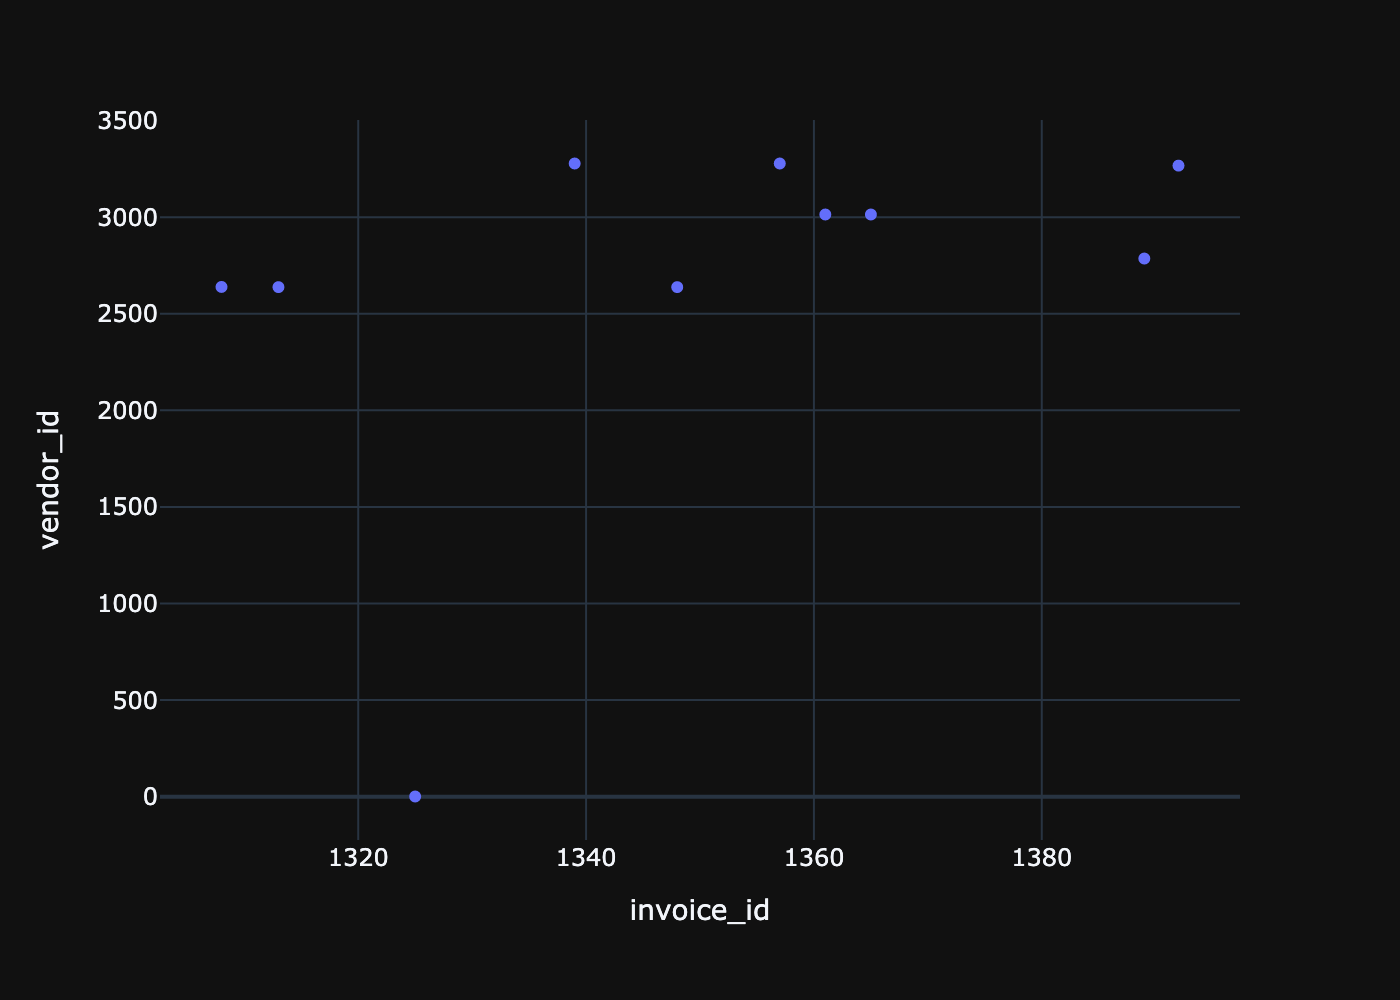

In [17]:
vanna_ans = vn.ask(question="Give me list of invoices from invoices table where total_amount is greater than 4000, arranged in descending order, limit to top 10")

In [18]:
vanna_ans

('SELECT *\nFROM invoices\nWHERE total_amount > 4000\nORDER BY total_amount DESC\nLIMIT 10',
    invoice_id invoice_number  \
 0        1392    50022934171   
 1        1313          05555   
 2        1325            #52   
 3        1357             52   
 4        1339            #52   
 5        1348            #52   
 6        1361  988213-MHCPFV   
 7        1365     3864/25237   
 8        1389   930006556-00   
 9        1308   930006556-00   
 
                            invoice_original_filename invoice_location  \
 0  20250407_021914-2023-08-08_PO-0163_PO-0165_Whi...        Originals   
 1  20250321_180715-urgent2025-01-27_Inv_05_Big Br...          Updated   
 2  20250324_214307-urgent2024-09-16_Inv_52_AnD Ma...          Deleted   
 3  20250327_022237-urgent2024-09-16_Inv_52_AnD Ma...          Deleted   
 4  20250326_104710-urgent2024-09-16_Inv_52_AnD Ma...        Originals   
 5  20250326_193529-urgent2024-09-16_Inv_52_AnD Ma...          Updated   
 6  20250402_155737-2023

In [20]:
vanna_ans[1]

TypeError: 'NoneType' object is not subscriptable

In [15]:
from vanna.flask import VannaFlaskApp
app = VannaFlaskApp(vn, allow_llm_to_see_data=True)
app.run()

Your app is running at:
http://localhost:8084
 * Serving Flask app 'vanna.flask'
 * Debug mode: on


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
